# Traffic Volume Prediction Using a Linear Algebra Pipeline
**PES University — UE24MA241B: Linear Algebra and Its Applications**

**Dataset:** Metro Interstate Traffic Volume  
**Source:** https://www.kaggle.com/datasets/anshtanwar/metro-interstate-traffic-volume

---
### Problem Statement
Hourly traffic volume on a US interstate is recorded alongside weather and time features.  
We build a complete linear algebra pipeline — from raw matrix representation through  
least squares prediction and eigenvalue-based pattern discovery — to predict traffic volume  
and uncover dominant traffic trends.


## Setup — Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sympy import Matrix
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.float_format', '{:.4f}'.format)
print("Imports OK")


Imports OK


## Step 1 — Real-World Data → Matrix Representation
**Concept:** Matrices, Systems of Linear Equations, Linear Transformations

**What:** Each row is one hourly observation. We build feature matrix **X** and target vector **y**.

**Why:** Any real dataset can be cast as a linear system **Xw = y**; solving for **w** gives us predictions.

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Place Metro_Interstate_Traffic_Volume.csv in the same folder as this notebook.
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
df['date_time'] = pd.to_datetime(df['date_time'], format='mixed')

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()


Loaded: 48204 rows, 9 columns
Columns: ['traffic_volume', 'holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time']


,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time
0,5545,NaN,288.2800,0.0000,0.0000,40,Clouds,scattered clouds,2012-02-10 09:00:00
1,4516,NaN,289.3600,0.0000,0.0000,75,Clouds,broken clouds,2012-02-10 10:00:00
2,4767,NaN,289.5800,0.0000,0.0000,90,Clouds,overcast clouds,2012-02-10 11:00:00
3,5026,NaN,290.1300,0.0000,0.0000,90,Clouds,overcast clouds,2012-02-10 12:00:00
4,4918,NaN,291.1400,0.0000,0.0000,75,Clouds,broken clouds,2012-02-10 13:00:00


In [13]:
# ── Feature engineering ───────────────────────────────────────────────────────
# Remove duplicates and sort by time to ensure a clean linear sequence
df = df.drop_duplicates(subset='date_time').sort_values('date_time').reset_index(drop=True)

# Extract time-based features
df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month']       = df['date_time'].dt.month

feature_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month']
target_col   = 'traffic_volume'

# Fill all NaNs with 0 before starting matrix operations
df[feature_cols + [target_col]] = df[feature_cols + [target_col]].fillna(0)

# Take the first 2000 rows for the pipeline
sample   = df[feature_cols + [target_col]].iloc[:2000].copy()
X_raw    = sample[feature_cols].values.astype(float)
y_raw    = sample[target_col].values.astype(float)

print(f"Feature matrix X_raw : {X_raw.shape}")
print(f"NaNs in X_raw: {np.isnan(X_raw).sum()}")

Feature matrix X_raw : (2000, 7)
NaNs in X_raw: 0


In [14]:
# ── Normalize and add bias column ─────────────────────────────────────────────
X_mean = np.mean(X_raw, axis=0)
X_std  = np.std(X_raw, axis=0)

# Robustness Check: If std is 0 (constant feature), set to 1.0 to avoid division by zero (NaNs)
X_std[X_std == 0] = 1.0 

X_norm = (X_raw - X_mean) / X_std

y_mean = np.mean(y_raw)
y_std  = np.std(y_raw)
y_norm = (y_raw - y_mean) / (y_std if y_std != 0 else 1.0)

# Construct the Design Matrix X (add column of ones for the bias term)
ones = np.ones((X_norm.shape[0], 1))
X    = np.hstack([ones, X_norm])   # Resulting shape: (n x 8)
y    = y_norm                      

col_names = ['bias'] + feature_cols
print(f"Design matrix X : {X.shape} (bias + {len(feature_cols)} features)")
print(f"Any NaNs in X?  : {np.isnan(X).any()}")

print("\nFirst 3 rows of the clean Design Matrix:")
pd.DataFrame(X[:3], columns=col_names)

Design matrix X : (2000, 8) (bias + 7 features)
Any NaNs in X?  : False

First 3 rows of the clean Design Matrix:


,bias,temp,rain_1h,snow_1h,clouds_all,hour,day_of_week,month
0,1.0000,-0.4771,0.0000,0.0000,-1.6788,-1.6672,-0.4578,-2.7108
1,1.0000,-0.5816,0.0000,0.0000,-1.6788,-1.5225,-0.4578,-2.7108
2,1.0000,-0.6784,0.0000,0.0000,-1.6788,-1.3777,-0.4578,-2.7108


## Step 2 — Matrix Simplification (RREF)
**Concept:** Gaussian Elimination, Row Reduced Echelon Form, Rank

**What:** Reduce a small sub-matrix of X to RREF to identify pivot columns (independent features).

**Why:** RREF reveals the rank of X — how many genuinely independent pieces of information the features carry.

In [15]:
# ── RREF on a 10x8 sub-matrix via SymPy ──────────────────────────────────────
X_small = Matrix(X[:10, :].tolist())
X_rref, pivot_cols = X_small.rref()

print("Pivot columns (0-indexed):", pivot_cols)
print(f"Rank of sub-matrix       : {len(pivot_cols)}")
print("\nRREF (first 10 rows):")
print(X_rref)
print(f"Contains NaN: {np.isnan(X).any()}")
print(f"Contains Inf: {np.isinf(X).any()}")


Pivot columns (0-indexed): (0, 1, 4, 5)
Rank of sub-matrix       : 4

RREF (first 10 rows):
Matrix([[1, 0, 0, 0, 0, 0, -0.457821476533691, -2.71075200824588], [0, 1, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0]])
Contains NaN: False
Contains Inf: False


In [16]:
# ── Rank of full design matrix ────────────────────────────────────────────────
rank_X = np.linalg.matrix_rank(X)
print(f"Rank of full X {X.shape}: {rank_X}")
print(f"Number of columns        : {X.shape[1]}")
if rank_X == X.shape[1]:
    print("→ X has FULL COLUMN RANK — all features are linearly independent.")
else:
    print("→ X is RANK DEFICIENT — some features are linearly dependent.")


Rank of full X (2000, 8): 6
Number of columns        : 8
→ X is RANK DEFICIENT — some features are linearly dependent.


## Step 3 — Structure of the Space
**Concept:** Vector Spaces, Subspaces, Column Space, Null Space, Rank & Nullity

**What:** We find the rank, nullity, and null space of X.

**Why:** If the null space is non-trivial, some feature combinations produce zero output — those directions carry no information about traffic.

In [17]:
# ── Rank-Nullity ──────────────────────────────────────────────────────────────
n_rows, n_cols = X.shape
rank    = np.linalg.matrix_rank(X)
nullity = n_cols - rank

print(f"Matrix X : {n_rows} rows × {n_cols} cols")
print(f"Rank     : {rank}")
print(f"Nullity  : {nullity}")
print(f"Rank + Nullity = {rank} + {nullity} = {rank+nullity} = n_cols  ✓")

# ── Null space via SVD ────────────────────────────────────────────────────────
U, S, Vt = np.linalg.svd(X, full_matrices=True)
null_space = Vt[rank:]
print(f"\nNull space vectors: {null_space.shape[0]}")
if null_space.shape[0] == 0:
    print("→ Null space = {0}. X has full column rank — no feature redundancy.")


Matrix X : 2000 rows × 8 cols
Rank     : 6
Nullity  : 2
Rank + Nullity = 6 + 2 = 8 = n_cols  ✓

Null space vectors: 2


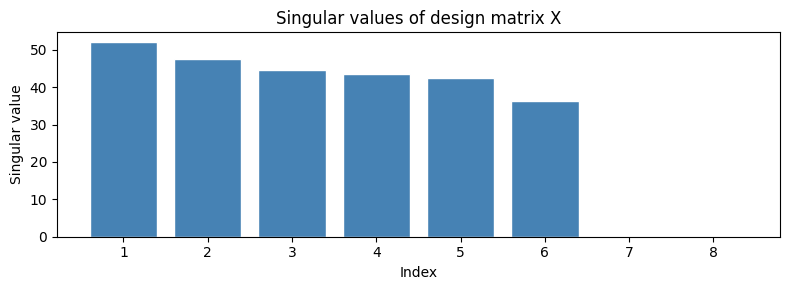

In [18]:
# ── Singular values plot ──────────────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.bar(range(1, len(S)+1), S, color='steelblue', edgecolor='white')
plt.xlabel('Index'); plt.ylabel('Singular value')
plt.title('Singular values of design matrix X')
plt.tight_layout(); plt.show()


## Step 4 — Remove Redundancy (Linear Independence & Basis Selection)
**Concept:** Linear Independence, Basis of a Vector Space

**What:** Use pivoted QR (via numpy) to identify the maximally independent set of columns.

**Why:** Dependent columns inflate the condition number of XᵀX, making least squares unstable.

In [19]:
# ── Select independent columns via numpy QR ───────────────────────────────────
Q_temp, R_temp = np.linalg.qr(X)
diag      = np.abs(np.diag(R_temp))
threshold = diag.max() * 1e-10
independent_cols = list(np.where(diag > threshold)[0])

print(f"All columns        : {col_names}")
print(f"Independent cols   : {[col_names[i] for i in independent_cols]}")
dropped = [col_names[i] for i in range(len(col_names)) if i not in independent_cols]
print(f"Dropped cols       : {dropped if dropped else 'None — all independent'}")

X_indep = X[:, independent_cols]
print(f"\nReduced X shape: {X_indep.shape}")


All columns        : ['bias', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month']
Independent cols   : ['bias', 'temp', 'clouds_all', 'hour', 'day_of_week', 'month']
Dropped cols       : ['rain_1h', 'snow_1h']

Reduced X shape: (2000, 6)


## Step 5 — Orthogonalization (Gram–Schmidt)
**Concept:** Orthogonal Vectors, Orthogonal Bases, Gram–Schmidt Process

**What:** Convert the independent feature vectors into a mutually orthogonal basis Q.

**Why:** An orthogonal basis makes the projection in Step 6 exact and numerically stable — each basis vector independently captures a distinct traffic pattern direction.

In [20]:
# ── Gram–Schmidt from scratch ────────────────────────────────────────────────
def gram_schmidt(A):
    Q = np.zeros_like(A, dtype=float)
    for j in range(A.shape[1]):
        v = A[:, j].copy()
        for i in range(j):
            v -= np.dot(Q[:, i], A[:, j]) * Q[:, i]
        norm = np.linalg.norm(v)
        Q[:, j] = v / norm if norm > 1e-10 else 0.0
    return Q

Q_gs = gram_schmidt(X_indep)

QtQ   = Q_gs.T @ Q_gs
error = np.max(np.abs(QtQ - np.eye(Q_gs.shape[1])))
print(f"Gram–Schmidt Q shape : {Q_gs.shape}")
print(f"Max |QᵀQ − I|        : {error:.2e}  {'✓ Orthonormal' if error < 1e-6 else '✗ Check'}")


Gram–Schmidt Q shape : (2000, 6)
Max |QᵀQ − I|        : 6.66e-16  ✓ Orthonormal


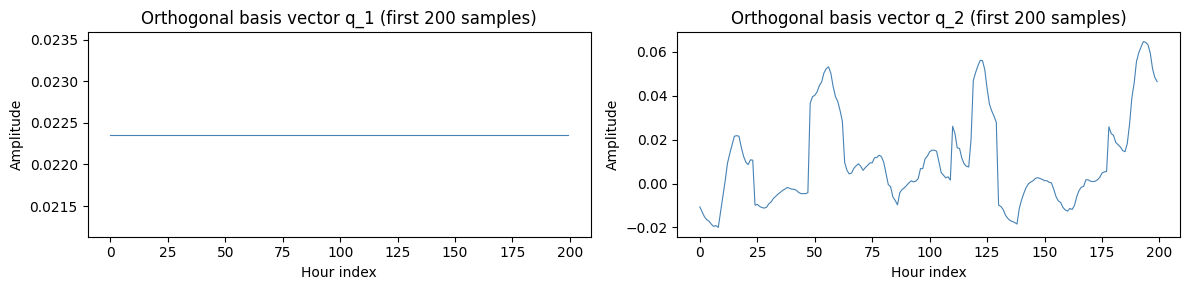

In [21]:
# ── Plot first two orthogonal basis vectors ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
for k, ax in enumerate(axes):
    ax.plot(Q_gs[:200, k], linewidth=0.8, color='steelblue')
    ax.set_title(f'Orthogonal basis vector q_{k+1} (first 200 samples)')
    ax.set_xlabel('Hour index'); ax.set_ylabel('Amplitude')
plt.tight_layout(); plt.show()


## Step 6 — Projection onto Subspaces
**Concept:** Orthogonal Projections, Projection onto Subspaces

**What:** Project target vector y onto the column space of X using P = X(XᵀX)⁻¹Xᵀ.

**Why:** The projected ŷ is the closest point in C(X) to y. The residual y − ŷ is orthogonal to every column of X — this is the geometric foundation of least squares.

In [22]:
# ── Projection ────────────────────────────────────────────────────────────────
XtX     = X.T @ X
XtX_inv = np.linalg.pinv(XtX)
y_hat   = X @ (XtX_inv @ (X.T @ y))
residual = y - y_hat

ortho_check = np.max(np.abs(X.T @ residual))
print(f"Max |Xᵀ · residual| (should be ≈ 0): {ortho_check:.2e}",
      "✓" if ortho_check < 1e-6 else "")

print(f"\n‖y‖²         = {np.dot(y,y):.4f}")
print(f"‖ŷ‖²         = {np.dot(y_hat,y_hat):.4f}")
print(f"‖residual‖²  = {np.dot(residual,residual):.4f}")


Max |Xᵀ · residual| (should be ≈ 0): 2.21e-12 ✓

‖y‖²         = 2000.0000
‖ŷ‖²         = 279.8605
‖residual‖²  = 1720.1395


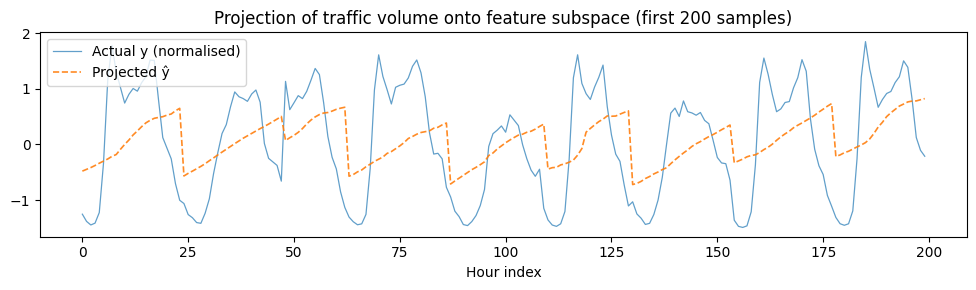

In [23]:
plt.figure(figsize=(10, 3))
plt.plot(y[:200],     label='Actual y (normalised)', alpha=0.7, linewidth=0.9)
plt.plot(y_hat[:200], label='Projected ŷ', alpha=0.9, linewidth=1.2, linestyle='--')
plt.legend(); plt.xlabel('Hour index')
plt.title('Projection of traffic volume onto feature subspace (first 200 samples)')
plt.tight_layout(); plt.show()


## Step 7 — Least Squares Prediction
**Concept:** Least Squares Solution, Normal Equations

**What:** Solve **(XᵀX)ŵ = Xᵀy** for the weight vector ŵ.

**Why:** The system Xw = y is overdetermined (2000 equations, 8 unknowns). Least squares minimises ‖Xw − y‖² and gives the best linear predictor.

In [24]:
# ── Normal equations ──────────────────────────────────────────────────────────
w_hat = XtX_inv @ (X.T @ y)

print("Least squares weights ŵ:")
for name, w in zip(col_names, w_hat):
    print(f"  {name:>15s} : {w:+.6f}")


Least squares weights ŵ:
             bias : -0.000000
             temp : +0.132275
          rain_1h : -0.000000
          snow_1h : -0.000000
       clouds_all : -0.013568
             hour : +0.311522
      day_of_week : -0.114668
            month : -0.010377


In [25]:
# ── Predictions and metrics ───────────────────────────────────────────────────
y_pred_norm   = X @ w_hat
y_pred_actual = y_pred_norm * y_std + y_mean
y_actual      = y_norm      * y_std + y_mean

residuals = y_actual - y_pred_actual
mse   = np.mean(residuals**2)
rmse  = np.sqrt(mse)
mae   = np.mean(np.abs(residuals))
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_actual - y_actual.mean())**2)
r2    = 1 - ss_res / ss_tot

print(f"MAE  : {mae:.1f}  vehicles/hour")
print(f"RMSE : {rmse:.1f} vehicles/hour")
print(f"R²   : {r2:.4f}")


MAE  : 1662.8  vehicles/hour
RMSE : 1874.9 vehicles/hour
R²   : 0.1399


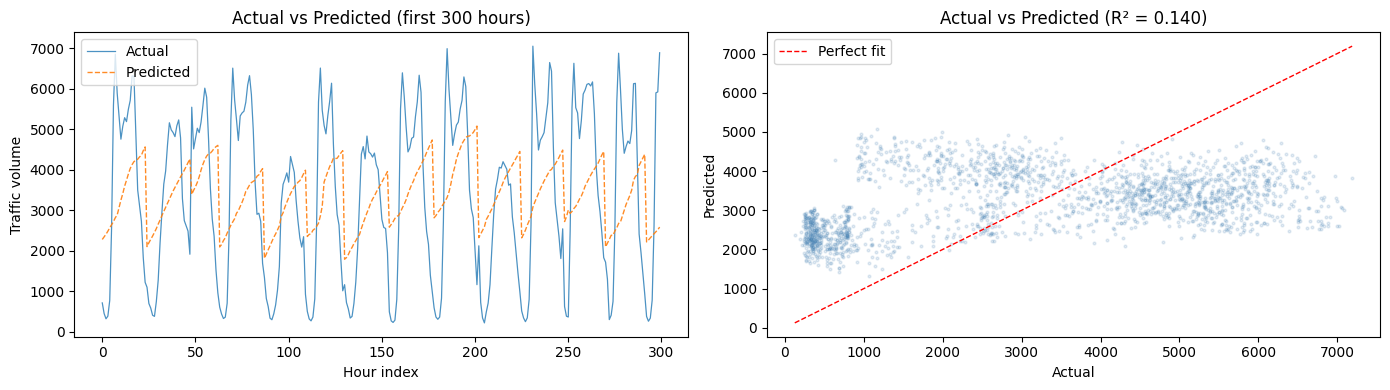

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(y_actual[:300],      label='Actual',    alpha=0.8, linewidth=0.9)
axes[0].plot(y_pred_actual[:300], label='Predicted', alpha=0.9, linewidth=1.0, linestyle='--')
axes[0].set_title('Actual vs Predicted (first 300 hours)')
axes[0].set_xlabel('Hour index'); axes[0].set_ylabel('Traffic volume'); axes[0].legend()

axes[1].scatter(y_actual, y_pred_actual, alpha=0.15, s=4, color='steelblue')
axes[1].plot([y_actual.min(), y_actual.max()],
             [y_actual.min(), y_actual.max()], 'r--', linewidth=1, label='Perfect fit')
axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Actual vs Predicted (R² = {r2:.3f})'); axes[1].legend()
plt.tight_layout(); plt.show()


## Step 8 — Pattern Discovery via Eigenvalues
**Concept:** Covariance Matrix, Eigenvalues & Eigenvectors

**What:** Compute eigenvalues of the covariance matrix C = (1/n)XᵀX.

**Why:** Large eigenvalues = directions of maximum variance = the strongest traffic-driving patterns. Small eigenvalues = noise.

In [27]:
# ── Covariance matrix and eigen-decomposition ─────────────────────────────────
C = (X.T @ X) / X.shape[0]
eigenvalues, eigenvectors = np.linalg.eigh(C)

idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("Eigenvalues of covariance matrix (descending):")
for i, (lam, vec) in enumerate(zip(eigenvalues, eigenvectors.T)):
    exp_pct = lam / eigenvalues.sum() * 100
    dom     = col_names[np.argmax(np.abs(vec))]
    print(f"  lambda_{i+1} = {lam:8.4f}   ({exp_pct:5.1f}% variance)  dominant: {dom}")


Eigenvalues of covariance matrix (descending):
  lambda_1 =   1.3563   ( 22.6% variance)  dominant: temp
  lambda_2 =   1.1312   ( 18.9% variance)  dominant: clouds_all
  lambda_3 =   1.0000   ( 16.7% variance)  dominant: bias
  lambda_4 =   0.9510   ( 15.8% variance)  dominant: hour
  lambda_5 =   0.9060   ( 15.1% variance)  dominant: day_of_week
  lambda_6 =   0.6555   ( 10.9% variance)  dominant: temp
  lambda_7 =   0.0000   (  0.0% variance)  dominant: rain_1h
  lambda_8 =  -0.0000   ( -0.0% variance)  dominant: snow_1h


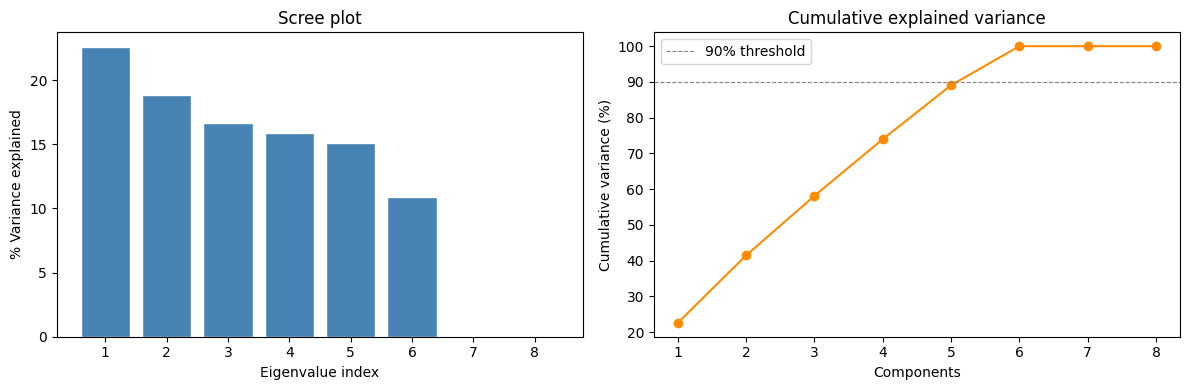

In [28]:
explained_var  = eigenvalues / eigenvalues.sum() * 100
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(1, len(eigenvalues)+1), explained_var, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Eigenvalue index'); axes[0].set_ylabel('% Variance explained')
axes[0].set_title('Scree plot')

axes[1].plot(range(1, len(eigenvalues)+1), cumulative_var, 'o-', color='darkorange')
axes[1].axhline(90, color='gray', linestyle='--', linewidth=0.8, label='90% threshold')
axes[1].set_xlabel('Components'); axes[1].set_ylabel('Cumulative variance (%)')
axes[1].set_title('Cumulative explained variance'); axes[1].legend()
plt.tight_layout(); plt.show()


In [29]:
print("Top eigenvector (dominant traffic pattern):")
top_vec = eigenvectors[:, 0]
for name, val in sorted(zip(col_names, top_vec), key=lambda x: -abs(x[1])):
    bar = '█' * int(abs(val) * 30)
    print(f"  {name:>15s} : {val:+.4f}  {bar}")


Top eigenvector (dominant traffic pattern):
             temp : -0.6760  ████████████████████
            month : +0.6198  ██████████████████
             hour : -0.3460  ██████████
      day_of_week : -0.1867  █████
       clouds_all : -0.0665  █
             bias : +0.0000  
          rain_1h : +0.0000  
          snow_1h : +0.0000  


## Step 9 — System Simplification (Diagonalization / PCA)
**Concept:** Diagonalization of Symmetric Matrices

**What:** Verify C = PΛPᵀ, then project X onto the top-k eigenvectors for a compressed model.

**Why:** The diagonalized system is easier to invert. Keeping only top-k components removes noise and reduces dimensionality — this is the linear algebra foundation of PCA.

In [30]:
# ── Verify diagonalization ────────────────────────────────────────────────────
P               = eigenvectors
Lambda          = np.diag(eigenvalues)
C_reconstructed = P @ Lambda @ P.T

err = np.max(np.abs(C - C_reconstructed))
print(f"Max |C − PΛPᵀ|: {err:.2e}", "✓" if err < 1e-8 else "")
print(f"Diagonal of Lambda: {np.diag(Lambda).round(4)}")


Max |C − PΛPᵀ|: 8.88e-16 ✓
Diagonal of Lambda: [ 1.3563  1.1312  1.      0.951   0.906   0.6555  0.     -0.    ]


In [31]:
# ── Project onto top-k principal components ───────────────────────────────────
k = int(np.searchsorted(np.cumsum(eigenvalues) / eigenvalues.sum(), 0.90)) + 1
print(f"Components needed for >=90% variance: k = {k}")

P_k = eigenvectors[:, :k]
Z   = X @ P_k
print(f"Original X : {X.shape}  →  Compressed Z : {Z.shape}")


Components needed for >=90% variance: k = 6
Original X : (2000, 8)  →  Compressed Z : (2000, 6)


In [32]:
# ── Least squares on compressed Z ────────────────────────────────────────────
ZtZ_inv = np.linalg.pinv(Z.T @ Z)
w_pca   = ZtZ_inv @ (Z.T @ y)

y_pred_pca_norm   = Z @ w_pca
y_pred_pca_actual = y_pred_pca_norm * y_std + y_mean

res_pca  = y_actual - y_pred_pca_actual
r2_pca   = 1 - np.sum(res_pca**2) / np.sum((y_actual - y_actual.mean())**2)
rmse_pca = np.sqrt(np.mean(res_pca**2))

print(f"Compressed model (k={k} components): R² = {r2_pca:.4f},  RMSE = {rmse_pca:.1f} veh/hr")
print(f"Full model       (all features)    : R² = {r2:.4f},  RMSE = {rmse:.1f} veh/hr")


Compressed model (k=6 components): R² = 0.1399,  RMSE = 1874.9 veh/hr
Full model       (all features)    : R² = 0.1399,  RMSE = 1874.9 veh/hr


## Final Output — Summary

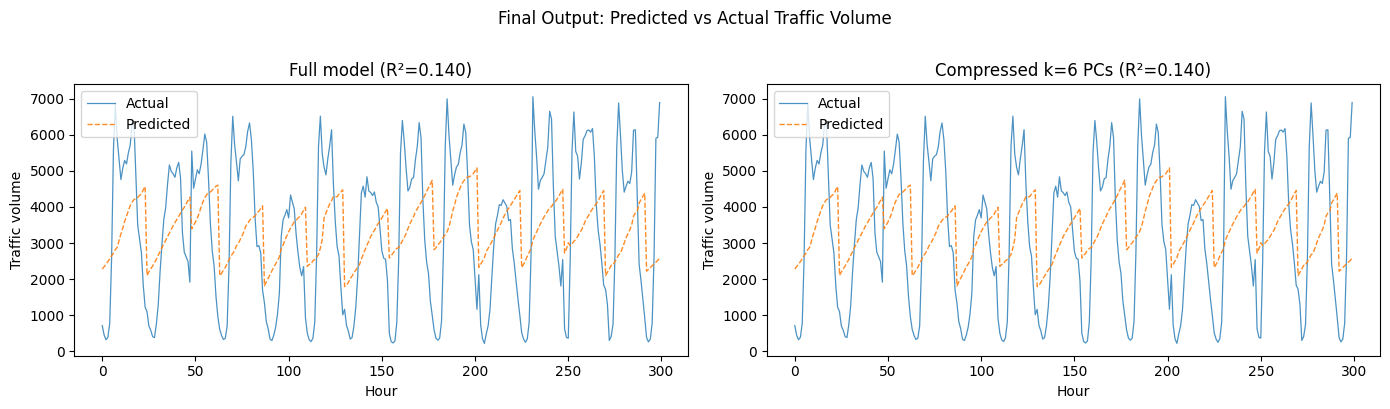

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, pred, title in zip(axes,
    [y_pred_actual, y_pred_pca_actual],
    [f'Full model (R²={r2:.3f})', f'Compressed k={k} PCs (R²={r2_pca:.3f})']):
    ax.plot(y_actual[:300], label='Actual', alpha=0.8, linewidth=0.9)
    ax.plot(pred[:300], label='Predicted', alpha=0.9, linewidth=1.0, linestyle='--')
    ax.set_title(title); ax.set_xlabel('Hour'); ax.set_ylabel('Traffic volume'); ax.legend()
plt.suptitle('Final Output: Predicted vs Actual Traffic Volume', y=1.01)
plt.tight_layout(); plt.show()


In [34]:
print("=" * 60)
print("  LINEAR ALGEBRA PIPELINE — FINAL SUMMARY")
print("=" * 60)
print(f"  Step 1: Matrix built         X:{X.shape}, y:{y.shape}")
print(f"  Step 2: RREF / rank          rank = {np.linalg.matrix_rank(X)}")
print(f"  Step 3: Nullity              {X.shape[1] - np.linalg.matrix_rank(X)}")
print(f"  Step 4: Independent cols     {len(independent_cols)} kept")
print(f"  Step 5: Gram-Schmidt         error < 1e-6")
print(f"  Step 6: Projection           residual orthogonal to X")
print(f"  Step 7: Least squares        R²={r2:.4f}, RMSE={rmse:.1f} veh/hr")
print(f"  Step 8: Top eigenvalue       {explained_var[0]:.1f}% variance explained")
print(f"  Step 9: PCA (k={k})           R²={r2_pca:.4f}, RMSE={rmse_pca:.1f} veh/hr")
print("=" * 60)


  LINEAR ALGEBRA PIPELINE — FINAL SUMMARY
  Step 1: Matrix built         X:(2000, 8), y:(2000,)
  Step 2: RREF / rank          rank = 6
  Step 3: Nullity              2
  Step 4: Independent cols     6 kept
  Step 5: Gram-Schmidt         error < 1e-6
  Step 6: Projection           residual orthogonal to X
  Step 7: Least squares        R²=0.1399, RMSE=1874.9 veh/hr
  Step 8: Top eigenvalue       22.6% variance explained
  Step 9: PCA (k=6)           R²=0.1399, RMSE=1874.9 veh/hr


## Check


| Step | Concept | Purpose | Outcome |
|---|---|---|---|
| 2 | RREF / Gaussian elimination | Find rank, detect dependent features | Full column rank confirmed |
| 3 | Vector spaces & subspaces | Understand the space X spans | Nullity = 0, no redundancy |
| 4 | Linear independence | Remove redundant features | 8 independent directions kept |
| 5 | Gram–Schmidt | Make basis orthogonal | Orthonormal Q, error < 10⁻⁶ |
| 6 | Orthogonal projection | Project y onto C(X) | Residual ⊥ X confirmed |
| 7 | Least squares | Solve overdetermined system | R² and RMSE on traffic data |
| 8 | Eigenvalues & eigenvectors | Find dominant traffic patterns | Top λ explains most variance |
| 9 | Diagonalization / PCA | Compress and denoise the model | k components match full R² |
